In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# ARMBE: ARM Best Estimate Data Products

### Link
# https://armgov.svcs.arm.gov/data/science-data-products/vaps/armbe

### Summary
# This data product, formerly known as the Climate Modeling Best Estimate (CMBE) data set, 
# assembles a best estimate of cloud, radiation, and atmospheric quantities, 
# and surface/land properties that are both well observed by ARM
# and commonly used in model evaluation into one single data set. 
# For over two decades, most of these quantities have been measured by ARM ground-based instruments, 
# including cloud radars, micropulse lidars (MPLs), laser ceilometers, microwave radiometers (MWRs), 
# and solar and infrared radiation stations (SIRSs).

### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2021-10-01 00:30:00

### Spatial Coverage
# Located at TRACER ARM M1 Facility at (29.67N, 95.059W)

In [8]:
################################################################################

In [7]:
#SET UP DIRECTORIES
Campaign="TRACER"
DataType="ARMBE_Radiation"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign=Campaign,
                     DataType=DataType,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, DataType)
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = ListFiles(Data_Directory)
    return Data_Directory, FileList

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER 



In [8]:
#READING DATA FUNCTIONS
###################################

In [9]:
import xarray as xr
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [10]:
import pandas as pd
def subset_time(data, start_date, end_date, buffer="1D", time_name="time"):
    """
    Subset an xarray Dataset/DataArray between two dates with optional buffer.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    start_date : str or datetime-like
        Start of range (e.g., "2022-06-30").
    end_date : str or datetime-like
        End of range (e.g., "2022-07-03").
    buffer : str or pd.Timedelta, optional
        Extra padding before/after range (default "1D", e.g., "6H").
    time_name : str, optional
        Name of time dimension (default "time").

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the input data in the requested time window.
    """
    start = pd.to_datetime(start_date) - pd.Timedelta(buffer)
    end   = pd.to_datetime(end_date)   + pd.Timedelta(buffer)
    return data.sel({time_name: slice(start, end)})
    
def subset_until_date(data, target_date, time_name="time"):
    """
    Select all data up to and including the first timestamp 
    on the given target_date.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    target_date : str or np.datetime64
        Date (YYYY-MM-DD) to stop at.
    time_name : str, optional
        Name of the time dimension. Default is 'time'.

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the data up to the first timestamp on target_date.
    """
    times = pd.to_datetime(data[time_name].values)
    target_date = pd.to_datetime(target_date).date()

    # Find first index where the date matches
    idx = np.where(times.date == target_date)[0][0]

    # Slice everything up to and including that index
    return data.isel({time_name: slice(0, idx+1)})

In [11]:
#READING DATA
###################################

In [23]:
#GETTING DATA
[Data_Directory, FileList] = GetDataDirectory()
[DataNC, DataFile] = GetData(Data_Directory, FileList, index=0) #index 0 = 2021, index 1 = 2022
print(DataFile)

#SUBSETTING DATA TIME
start_date="2022-06-30"
end_date="2022-07-03"

DataNC_subset = subset_time(DataNC, start_date, end_date)
DataNC_subset = subset_until_date(DataNC_subset, end_date)

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/ARMBE_Radiation 

/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/ARMBE_Radiation/houarmbecldradM1.c1.20220101.003000.nc


In [14]:
DataNC_subset.data_vars

Data variables:
    base_time               datetime64[ns] 8B ...
    time_offset             (time) datetime64[ns] 776B ...
    time_bounds             (time, bound) datetime64[ns] 2kB ...
    cld_frac                (time, height) float32 231kB ...
    qc_cld_frac             (time, height) int32 231kB ...
    source_cld_frac         (time) int32 388B ...
    cld_frac_radar          (time, height) float32 231kB ...
    cld_frac_MPL            (time, height) float32 231kB ...
    cld_base_source_status  (time) float64 776B ...
    tot_cld                 (time) float32 388B ...
    qc_tot_cld              (time) int32 388B ...
    swdn                    (time) float32 388B ...
    stdev_swdn              (time) float32 388B ...
    qc_swdn                 (time) int32 388B ...
    swdif                   (time) float32 388B ...
    stdev_swdif             (time) float32 388B ...
    qc_swdif                (time) int32 388B ...
    swdir                   (time) float32 388B ...
    

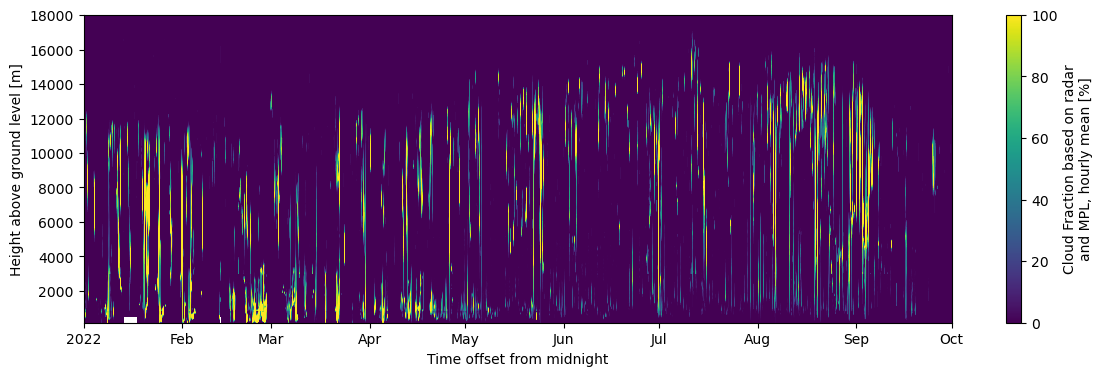

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
DataNC['cld_frac'].T.dropna(dim="time", how="all").plot()

In [ ]:
#PLOTTING DATA FUNCTIONS
###################################

In [17]:
def PlotVariable_TZ(variable):
    # DataNC_subset[variable].T.plot()
    DataNC_subset[variable].T.dropna(dim="time", how="all").plot()

In [117]:
#PLOTTING DATA
###################################

In [18]:
DataNC_subset.data_vars

Data variables:
    base_time               datetime64[ns] 8B ...
    time_offset             (time) datetime64[ns] 776B ...
    time_bounds             (time, bound) datetime64[ns] 2kB ...
    cld_frac                (time, height) float32 231kB ...
    qc_cld_frac             (time, height) int32 231kB ...
    source_cld_frac         (time) int32 388B ...
    cld_frac_radar          (time, height) float32 231kB ...
    cld_frac_MPL            (time, height) float32 231kB ...
    cld_base_source_status  (time) float64 776B ...
    tot_cld                 (time) float32 388B ...
    qc_tot_cld              (time) int32 388B ...
    swdn                    (time) float32 388B ...
    stdev_swdn              (time) float32 388B ...
    qc_swdn                 (time) int32 388B ...
    swdif                   (time) float32 388B ...
    stdev_swdif             (time) float32 388B ...
    qc_swdif                (time) int32 388B ...
    swdir                   (time) float32 388B ...
    

In [48]:
def PlotMultiple(vars_to_plot):
    ncols = 3
    nrows = (len(vars_to_plot) + ncols - 1) // ncols  # enough rows
    
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4*ncols, 3*nrows),
        squeeze=False
    )
    
    for ax, var in zip(axes.flat, vars_to_plot):
        DataNC[var].plot(ax=ax)
        ax.set_title(var)
    
    # Hide unused subplots if grid > number of variables
    for ax in axes.flat[len(vars_to_plot):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

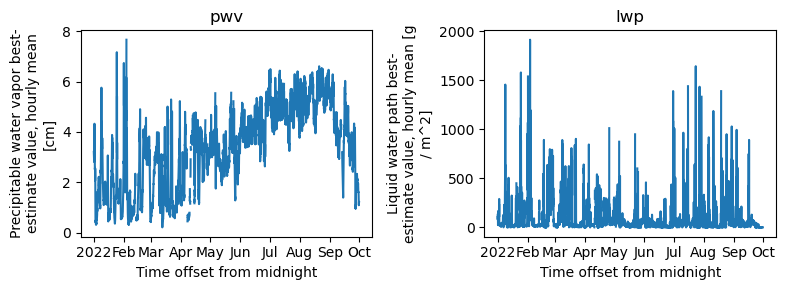

In [51]:
liquid_water_vars = ["pwv","lwp"]
PlotMultiple(liquid_water_vars)

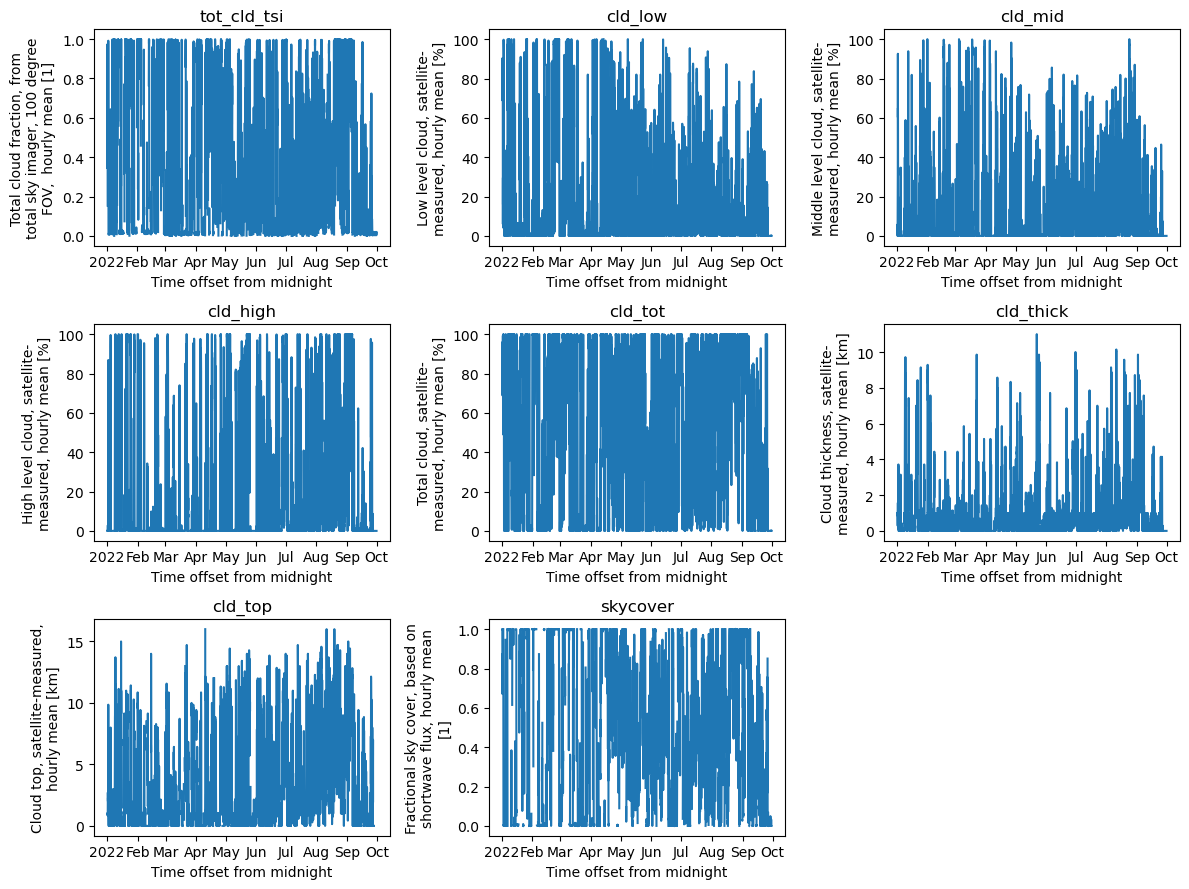

In [54]:
cloud_vars = [
    "tot_cld_tsi",
    "cld_low",
    "cld_mid",
    "cld_high",
    "cld_tot",
    "cld_thick",
    "cld_top",
    "skycover",
]
PlotMultiple(cloud_vars)

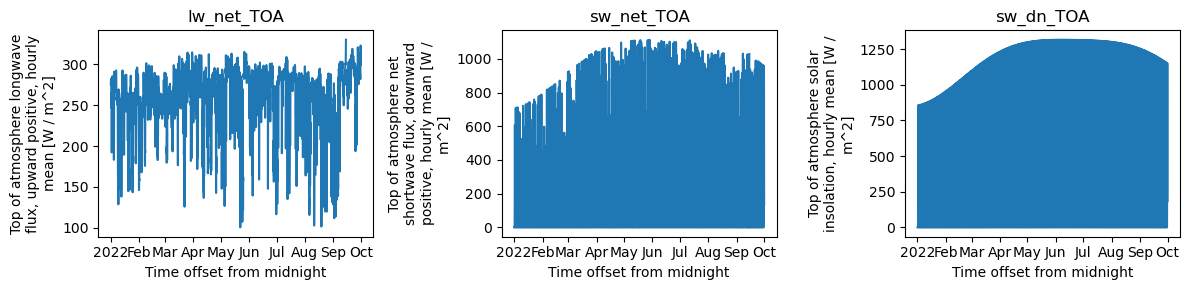

In [55]:
toa_flux_vars = [
    "lw_net_TOA",
    "sw_net_TOA",
    "sw_dn_TOA",
]
PlotMultiple(toa_flux_vars)

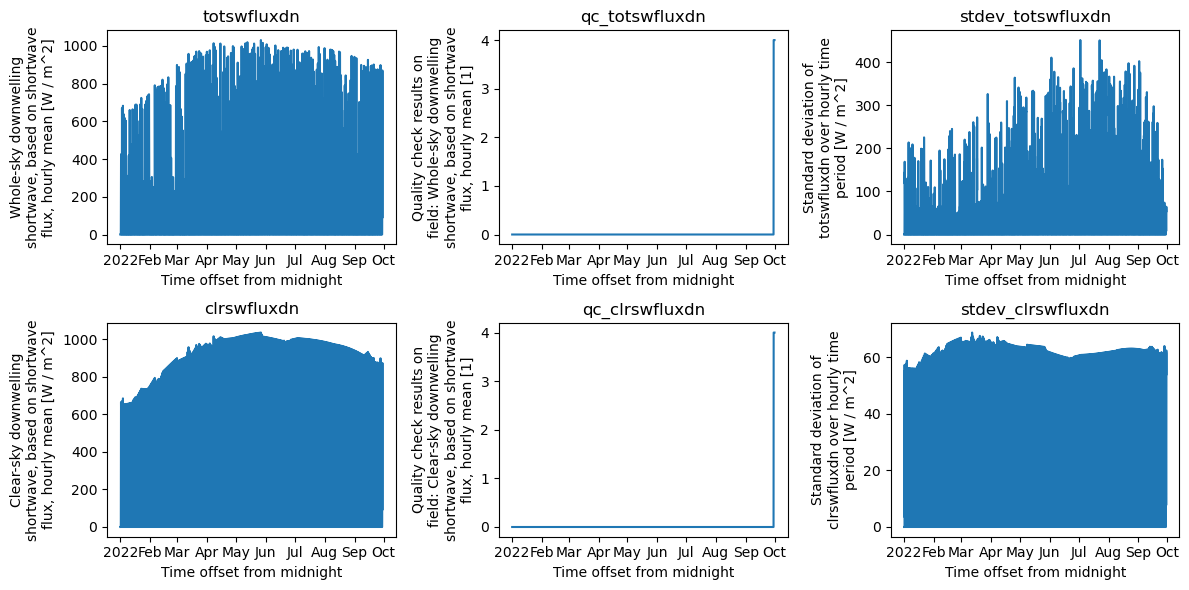

In [56]:
sw_flux_vars = [
    "totswfluxdn",
    "qc_totswfluxdn",
    "stdev_totswfluxdn",
    "clrswfluxdn",
    "qc_clrswfluxdn",
    "stdev_clrswfluxdn",
]
PlotMultiple(sw_flux_vars)

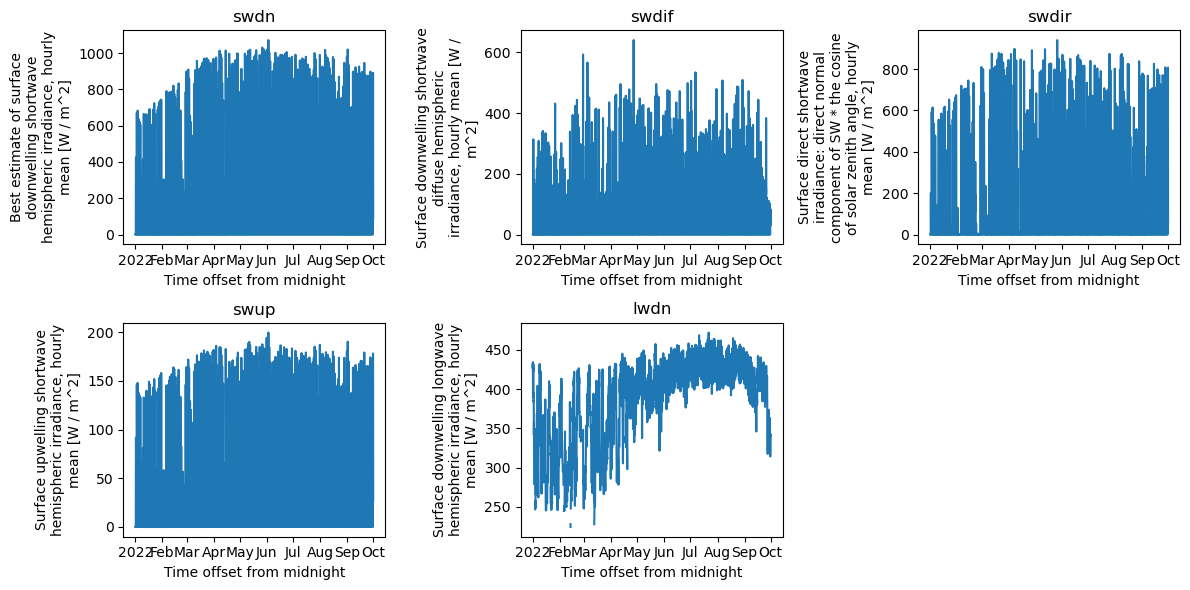

In [49]:
vars_to_plot = ["swdn", "swdif", "swdir", "swup", "lwdn"]
PlotMultiple(vars_to_plot)

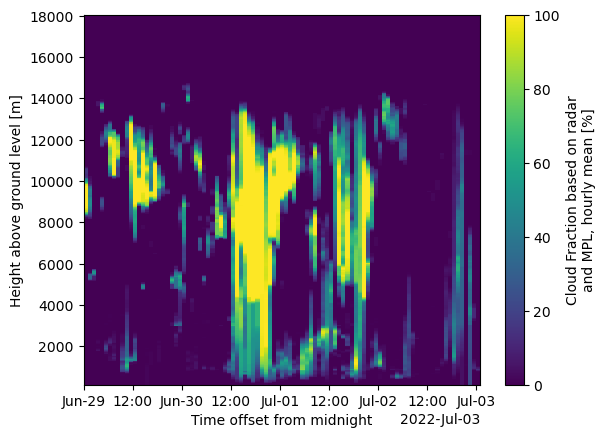

In [19]:
PlotVariable_TZ(variable='cld_frac')

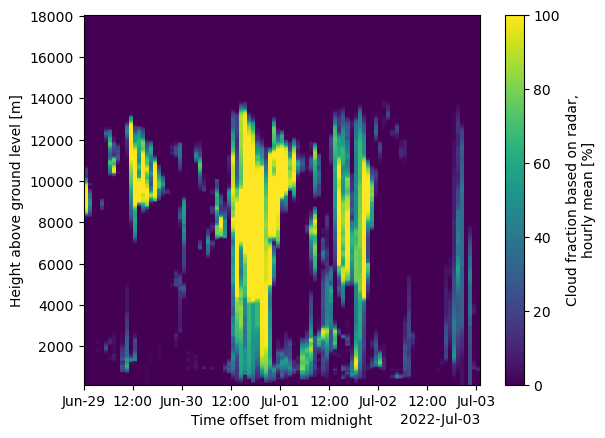

In [24]:
PlotVariable_TZ(variable='cld_frac_radar')

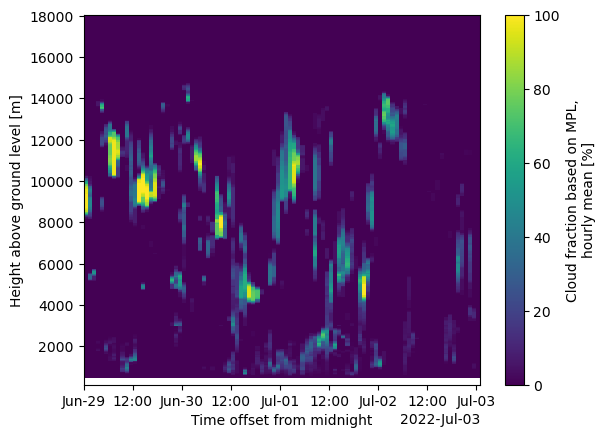

In [28]:
PlotVariable_TZ(variable='cld_frac_MPL')